In [1]:
from atproto import Client
from dotenv import load_dotenv
import os, time, json, datetime as dt
import pandas as pd

In [2]:
load_dotenv()

True

In [3]:
HANDLE = os.getenv("BSKY_HANDLE")
APP_PW = os.getenv("BSKY_APP_PASSWORD")

client = Client()
client.login(HANDLE, APP_PW)

ProfileViewDetailed(did='did:plc:z4gbcpr5mbkblvaybyj7lb4o', handle='nbtkmy.bsky.social', associated=ProfileAssociated(activity_subscription=ProfileAssociatedActivitySubscription(allow_subscriptions='followers', py_type='app.bsky.actor.defs#profileAssociatedActivitySubscription'), chat=None, feedgens=0, labeler=False, lists=0, starter_packs=0, py_type='app.bsky.actor.defs#profileAssociated'), avatar='https://cdn.bsky.app/img/avatar/plain/did:plc:z4gbcpr5mbkblvaybyj7lb4o/bafkreifbycx2uctdi434fqhko3nunethgikaaj4ib4gyawm2cty5cb7vkm@jpeg', banner='https://cdn.bsky.app/img/banner/plain/did:plc:z4gbcpr5mbkblvaybyj7lb4o/bafkreigqbemylzaqto7i6jmqagykj2daah3nrq6yh2lhd3tlnlafcblcim@jpeg', created_at='2023-12-22T17:06:17.158Z', description='A liaison librarian in Zurich', display_name='Nobutake Kamiya', followers_count=47, follows_count=146, indexed_at='2024-01-26T03:41:05.174Z', joined_via_starter_pack=None, labels=[], pinned_post=None, posts_count=5, pronouns=None, status=None, verification=None

In [5]:
cursor = None
all_posts = []
target_count = 1000

while True:
    res = client.app.bsky.feed.search_posts(
        params={"q": "AfD", "limit": 100, "lang": "de", "cursor": cursor}
    )
    all_posts.extend(res.posts)

    if not res.cursor or len(all_posts) > 10000:
        break
        
    if len(all_posts) > target_count:
        print(f"{target_count} Posts gesammelt")
        target_count += 1000
    
    cursor = res.cursor

1000 Posts gesammelt
2000 Posts gesammelt
3000 Posts gesammelt
4000 Posts gesammelt
5000 Posts gesammelt
6000 Posts gesammelt
7000 Posts gesammelt
8000 Posts gesammelt
9000 Posts gesammelt


In [8]:
data_list = []

for i in all_posts:
    
    post_data = {
        "post_created": i.record.created_at, 
        "text": i.record.text, 
        "like_count": i.like_count, 
        "quote_count": i.quote_count, 
        "reply_count": i.reply_count, 
        "repost_count": i.repost_count
    }
    
    data_list.append(post_data)
    
df = pd.DataFrame(data_list)
df.head()

,post_created,text,like_count,quote_count,reply_count,repost_count
0,2025-10-26T22:31:56.765Z,"Uninteressant, weil wir keinen Einfluss darauf...",0,0,0,0
1,2025-10-26T22:28:21.960Z,Same in Germany! Anti AfD/ Anti Rightwing Prot...,0,0,0,0
2,2025-10-26T22:19:51.346Z,"Überlegt mal, wie die Pegida-Demos auch dann n...",0,0,0,0
3,2025-10-26T22:14:44.057Z,Man denke an die Plan von #Alsleben mit der #M...,1,0,0,0
4,2025-10-26T22:14:29.274Z,"Das hat ganz gut funktioniert, solange es die ...",0,0,0,0


In [9]:
df.to_csv("../data/bluesky.csv")

In [50]:
# Wenn die DF als eine CSV-Tabelle einmal gespeichert ist, muss man nicht erneut die Posts von BlueSky holen
blue_sky_df = pd.read_csv("../data/bluesky.csv")
demo_df = blue_sky_df.sample(n=30)

# Analyse mit GPT-4.1mini

In [11]:
from __future__ import annotations
from typing import Dict, Any, List
import matplotlib.pyplot as plt
from openai import OpenAI

In [46]:
SUMMARY_SENTIMENT_SCHEMA = {
    "name": "SummarySentimentClaims",
    "schema": {
        "$schema": "http://json-schema.org/draft-07/schema#",
        "type": "object",
        "properties": {
            "summary": {"type": "string", "description": "One-sentence neutral summary (<= 30 words)."},
            "sentiment": {"type": "string", "enum": ["positive","neutral","negative","mixed"]},
            "claim_type": {
                "type": "string",
                "enum": [
                    "reporting",
                    "personal_experience", 
                    "opinion", 
                    "speculation", 
                    "rumor",
                    "request_for_info",
                    "other"
                ]
            },
            "certainty": {"type": "string", "enum": ["certain","uncertain"]},
            "has_source_reference": {"type": "boolean"},
            "model_rationale": {"type": "string", "description": "<= 25 words explaining labels.", "maxLength": 200}
        },
        "required": ["summary","sentiment","claim_type","certainty","has_source_reference","model_rationale"],
        "additionalProperties": False
        },
    "strict": True
}


MODERATION_ATTITUDE_SCHEMA = {
    "name": "ModerationAttitude",
    "schema": {
        "$schema": "http://json-schema.org/draft-07/schema#",
        "type": "object",
        "properties": {
            "attitude": {
            "type": "string",
            "enum": [
                "pro_regulation",
                "free_speech",
                "skeptical_or_mixed",
                "neutral_or_irrelevant"
            ]
            },
            "stance_strength": {"type": "number", "minimum": 0, "maximum": 1},
            "model_rationale": {"type": "string", "maxLength": 200}
        },
        "required": ["attitude","stance_strength","model_rationale"],
        "additionalProperties": False
    },
    "strict": True
}


MEME_STRUCTURE_SCHEMA = {
    "name": "MemeStructure",
    "schema": {
        "$schema": "http://json-schema.org/draft-07/schema#",
        "type": "object",
        "properties": {
            "meme_type": {
            "type": "string",
            "enum": [
                "irony_or_sarcasm",
                "pun_or_wordplay",
                "self_reference",
                "copypasta_or_template",
                "call_and_response",
                "absurdist_or_shitpost",
                "other",
                "none"
            ]
            },
            "is_meme": {"type": "boolean"},
            "model_rationale": {"type": "string", "maxLength": 200}
        },
        "required": ["meme_type","is_meme","model_rationale"],
        "additionalProperties": False
    },
    "strict": True
}


TASK_TO_SCHEMA = {
    "summary_sentiment_claims": SUMMARY_SENTIMENT_SCHEMA,
    "moderation_attitude": MODERATION_ATTITUDE_SCHEMA,
    "meme_structure": MEME_STRUCTURE_SCHEMA,
}

In [24]:
SYSTEM_PROMPT = (
"Du analysierst als erfahrener Soziologe die Posten in BlueSky."
"Alle hier gesammelten Posten thematisieren 'AfD (Alternative für Deutschland)'. "
"Folge die vordefinierten Taxonomie genau und führe die Klassifizierung der Post akurat aus."
"Liefere nur die JSON-Datei als Ergebnis. "
)


USER_INSTRUCTION_TMPL = (
"Klassifiziere den folgenden Post."
"Text:" + 
"""
{post_text}
"""
)

In [35]:
def _call_model(client, model: str, schema: Dict[str, Any], content: str, *, temperature: float = 0.2, seed: int | None = None, max_retries: int = 5) -> Dict[str, Any]:

    def _responses_call():
        return client.responses.create(
            model=model,
            input=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": content},
            ],
            response_format={
                "type": "json_schema",
                "json_schema": schema,
            },
            temperature=temperature,
            top_p=1.0,
            seed=seed,
        )


    def _chat_call_with_schema():
    
        return client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": content},
            ],
            response_format={
                "type": "json_schema",
                "json_schema": schema,
            },
            temperature=temperature,
            top_p=1.0,
            seed=seed,
        )


    def _chat_call_json_prompt():
    
        json_guidance = (
            "Return ONLY valid minified JSON that matches this JSON Schema. "
            "No markdown, no prose. If unsure, choose the closest label and set uncertainty fields accordingly."
        )
        return client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT + " " + json_guidance},
                {"role": "user", "content": content},
            ],
            temperature=temperature,
            top_p=1.0,
            seed=seed,
        )

    import json
    import time
    
    
    delay = 1.0
    last_err = None
    for attempt in range(max_retries):
        try:
        # Path 1: Responses API structured outputs
            try:
                resp = _responses_call()
                out = resp.output[0].content[0].json
                meta = {
                    "_model": getattr(resp, "model", model),
                    "_system_fingerprint": getattr(resp, "system_fingerprint", None),
                    "_seed": seed,
                }
                out["_meta"] = meta
                return out
            except TypeError:
            # response_format kw unsupported -> try chat path
                pass
    
    
            # Path 2: Chat Completions with schema
            try:
                c = _chat_call_with_schema()
                raw = c.choices[0].message["content"] if isinstance(c.choices[0].message, dict) else c.choices[0].message.content
                out = json.loads(raw)
                meta = {
                    "_model": getattr(c, "model", model),
                    "_system_fingerprint": getattr(c, "system_fingerprint", None),
                    "_seed": seed,
                }
                out["_meta"] = meta
                return out
            except TypeError:
                # Older chat API without response_format
                pass
        
    
            # Path 3: Chat Completions with JSON-only prompt
            c = _chat_call_json_prompt()
            raw = c.choices[0].message["content"] if isinstance(c.choices[0].message, dict) else c.choices[0].message.content
            out = json.loads(raw)
            meta = {
                "_model": getattr(c, "model", model),
                "_system_fingerprint": getattr(c, "system_fingerprint", None),
                "_seed": seed,
            }
            out["_meta"] = meta
            return out
      
        except Exception as e:
            last_err = e
            if attempt == max_retries - 1:
                raise
            time.sleep(delay)
            delay = min(delay * 2, 16)
              
    raise RuntimeError(f"Model call failed after retries: {last_err}")

In [41]:
def annotate_df(df: pd.DataFrame, client, task: str, text_col: str = "text", model: str = "gpt-4.1", seed: int | None = None) -> pd.DataFrame:

    if task not in TASK_TO_SCHEMA:
        raise ValueError(f"Unknown task: {task}")
    if text_col not in df.columns:
        raise ValueError(f"Missing text column: {text_col}")

    schema = TASK_TO_SCHEMA[task]


    results: List[Dict[str, Any]] = []
    for text in df[text_col].astype(str).tolist():
        content = USER_INSTRUCTION_TMPL.format(post_text=text.strip())
        out = _call_model(client, model=model, schema=schema, content=content, seed=seed)
        results.append(out)
    
    
    out_df = df.copy()


    if task == "summary_sentiment_claims":
        out_df["summary"] = [r.get("summary") for r in results]
        out_df["sentiment"] = [r.get("sentiment") for r in results]
        out_df["claim_type"] = [r.get("claim_type") for r in results]
        out_df["certainty"] = [r.get("certainty") for r in results]
        out_df["has_source_reference"] = [r.get("has_source_reference") for r in results]
        out_df["model_rationale"] = [r.get("model_rationale") for r in results]
    
    
    elif task == "moderation_attitude":
        out_df["attitude"] = [r.get("attitude") for r in results]
        out_df["stance_strength"] = [r.get("stance_strength") for r in results]
        out_df["model_rationale"] = [r.get("model_rationale") for r in results]
    
    
    elif task == "meme_structure":
        out_df["meme_type"] = [r.get("meme_type") for r in results]
        out_df["is_meme"] = [r.get("is_meme") for r in results]
        out_df["model_rationale"] = [r.get("model_rationale") for r in results]
    
    
    # Attach metadata columns (same for all tasks)
    out_df["model"] = [r.get("_meta", {}).get("_model") for r in results]
    out_df["system_fingerprint"] = [r.get("_meta", {}).get("_system_fingerprint") for r in results]
    out_df["seed"] = [r.get("_meta", {}).get("_seed") for r in results]
    
    
    return out_df

In [37]:
def plot_label_counts(df: pd.DataFrame, column: str, title: str | None = None):
    counts = df[column].value_counts(dropna=False)
    plt.figure()
    counts.plot(kind="bar")
    plt.xlabel(column)
    plt.ylabel("count")
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()

In [38]:
def plot_time_series(df: pd.DataFrame, time_col: str = "created_at", label_col: str = "sentiment", freq: str = "D"):

    if time_col not in df.columns:
        raise ValueError(f"Missing time column: {time_col}")
    tmp = df.copy()
    tmp[time_col] = pd.to_datetime(tmp[time_col], errors="coerce")
    tmp = tmp.dropna(subset=[time_col])
    grp = tmp.groupby([pd.Grouper(key=time_col, freq=freq), label_col]).size().unstack(fill_value=0)
    plt.figure()
    grp.plot()
    plt.xlabel(time_col)
    plt.ylabel("count")
    plt.title(f"{label_col} over time ({freq})")
    plt.tight_layout()
    plt.show()

In [39]:
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
SEED = 20251027

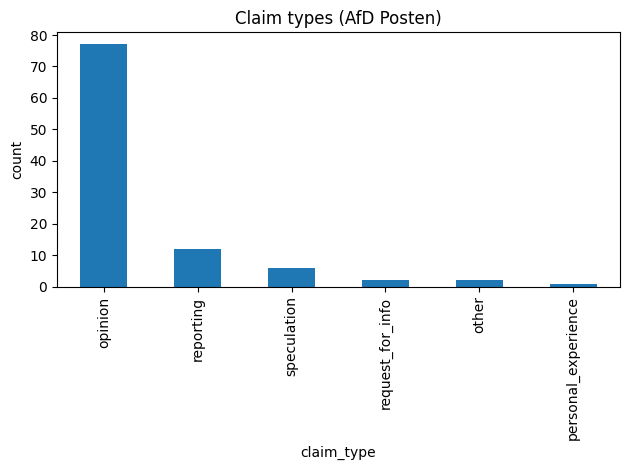

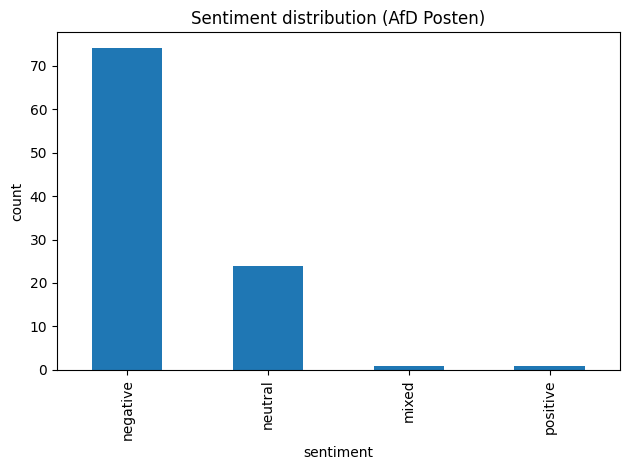

In [49]:
out = annotate_df(demo_df, client, task="summary_sentiment_claims", seed=SEED)
plot_label_counts(out, column="claim_type", title="Claim types (AfD Posten)")
plot_label_counts(out, column="sentiment", title="Sentiment distribution (AfD Posten)")